# Campus Placement Analytics & Prediction
**Author:** Aryan Verma | B.Tech CSE (AI & ML)

**Questions:** What decides who gets placed, and at what salary? Can we predict both?

**Data:** Kaggle *Student Placement Details* (synthetic), 10,000 students, 13 columns.
**Flow:** Load, audit, clean, analyse, predict placement (classification), predict salary (regression).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error, r2_score
sns.set_theme(style="whitegrid")

## 1. Load and inspect
One CSV only, so no merging is needed.

In [2]:
df = pd.read_csv("student_placement_dataset.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (10000, 13)


,student_id,name,branch,cgpa,avg_test_score,technical_score,aptitude_score,num_projects,num_internships,skills,placed,company,salary
0,S00001,Neha,IT,6.41,77.84,63.75,55.33,3,2,"HTML, Node",1,TCS,439921
1,S00002,Sneha,CIVIL,7.31,70.08,48.26,62.61,3,1,"STAAD, AutoCAD, Surveying, Revit",0,NaN,0
2,S00003,Priya,ECE,8.29,76.55,69.29,47.57,0,1,"C++, C",0,NaN,0
3,S00004,Karan,IT,7.67,59.86,72.22,69.11,2,1,"HTML, Java, Express, SQL",1,Accenture,1008601
4,S00005,Riya,CSE,8.42,71.43,85.83,77.05,3,0,"DL, Node, DataScience, HTML",1,Accenture,1015635
5,S00006,Shreya,CSE,8.07,63.01,83.65,53.83,2,1,"HTML, Java, C++, Python",1,TCS,645565
6,S00007,Priya,CSE,7.63,57.80,83.42,70.20,2,0,"Node, C++, ML, DataScience",0,NaN,0
7,S00008,Vihaan,MECH,6.83,61.39,65.02,60.34,6,1,"MATLAB, SolidWorks, AutoCAD, Python",0,NaN,0
8,S00009,Aisha,ECE,7.18,64.56,65.43,78.03,3,0,"C++, Embedded, C",1,TCS,479388
9,S00010,Karan,ECE,6.85,82.45,74.68,42.23,1,1,"Python, C++, C",0,NaN,0


## 2. Data quality audit
Checked before changing anything: duplicates, missing values, formatting.

In [3]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate student_id:", df['student_id'].duplicated().sum())
print("\nMissing values:\n", df.isna().sum()[lambda s: s > 0])
print("\nUnplaced students:", (df.placed == 0).sum())
print("Salary == 0 rows   :", (df.salary == 0).sum())
print("\nBranch values:", df.branch.unique().tolist())

Exact duplicate rows: 0
Duplicate student_id: 0

Missing values:
 company    2895
dtype: int64

Unplaced students: 2895
Salary == 0 rows   : 2895

Branch values: ['IT', 'CIVIL', 'ECE', 'CSE', 'MECH']


**Findings:** no duplicates; `company` is empty only for unplaced students (expected); salary `0` is a placeholder, not a real salary; branch is clean but uses short codes.

In [4]:
names = {"CSE": "Computer Science & Engg", "IT": "Information Technology",
         "ECE": "Electronics & Communication", "MECH": "Mechanical Engg", "CIVIL": "Civil Engg"}
df["branch"] = df["branch"].map(names)
df["salary_lpa"] = (df["salary"] / 1e5).round(2)
df.loc[df.placed == 0, ["salary", "salary_lpa"]] = np.nan
df = df.drop_duplicates()
print("Clean shape:", df.shape, "| missing salary:", df.salary_lpa.isna().sum())

Clean shape: (10000, 14) | missing salary: 2895


## 3. Placement patterns

branch
Computer Science & Engg        12.55
Information Technology         10.64
Electronics & Communication     8.64
Mechanical Engg                 6.72
Civil Engg                      5.73

Overall placement rate: 71.0%


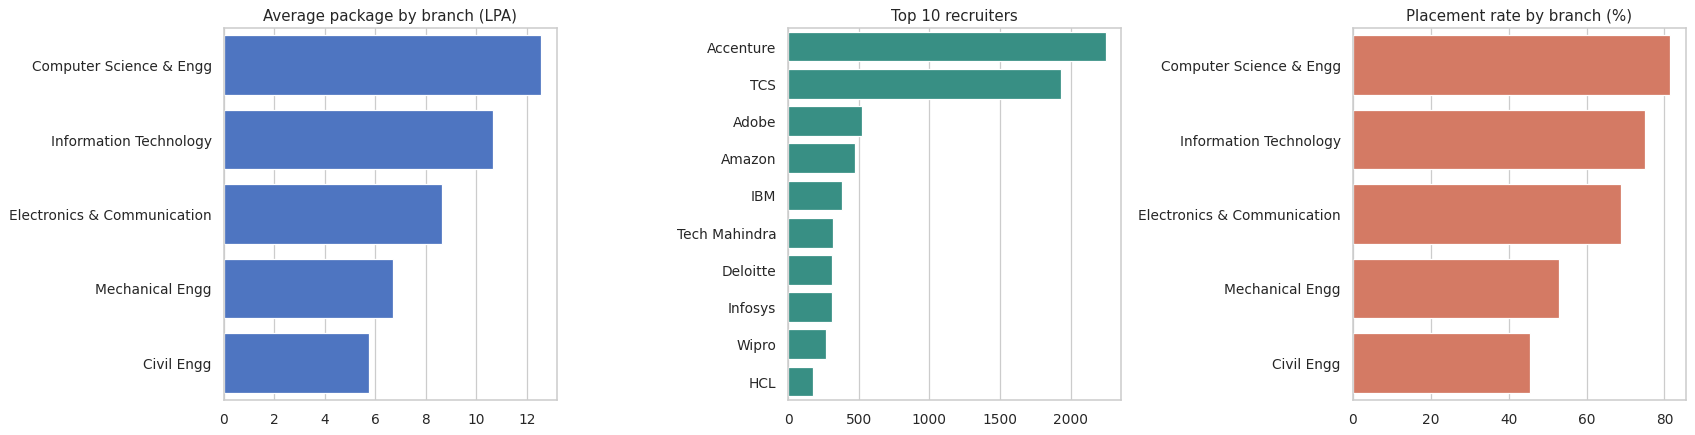

In [5]:
placed = df[df.placed == 1]
avg_pkg = placed.groupby("branch")["salary_lpa"].mean().sort_values(ascending=False)
rate = (df.groupby("branch")["placed"].mean() * 100).sort_values(ascending=False)
top_co = placed["company"].value_counts().head(10)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(x=avg_pkg.values, y=avg_pkg.index, ax=ax[0], color="#3b6fd4"); ax[0].set_title("Average package by branch (LPA)")
sns.barplot(x=top_co.values, y=top_co.index, ax=ax[1], color="#2a9d8f"); ax[1].set_title("Top 10 recruiters")
sns.barplot(x=rate.values, y=rate.index, ax=ax[2], color="#e76f51"); ax[2].set_title("Placement rate by branch (%)")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()
print(avg_pkg.round(2).to_string()); print("\nOverall placement rate: %.1f%%" % (df.placed.mean()*100))

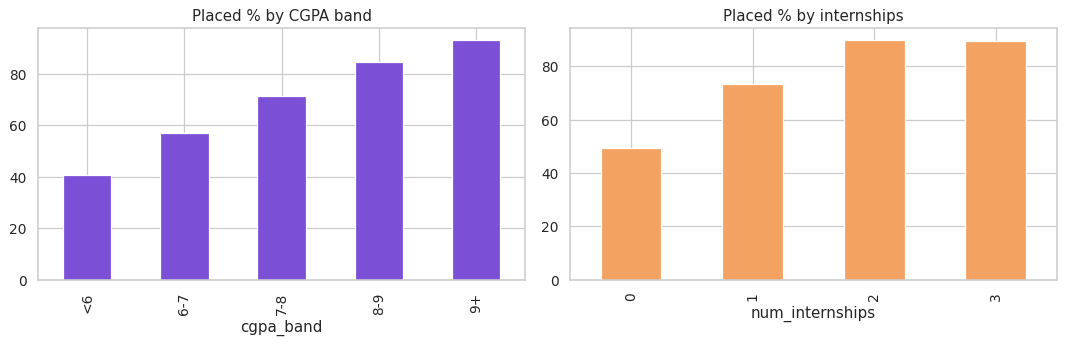

In [6]:
df["cgpa_band"] = pd.cut(df.cgpa, [0, 6, 7, 8, 9, 10.1], labels=["<6", "6-7", "7-8", "8-9", "9+"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(df.groupby("cgpa_band", observed=True).placed.mean() * 100).plot.bar(ax=ax[0], color="#7b4fd6", title="Placed % by CGPA band")
(df.groupby("num_internships").placed.mean() * 100).plot.bar(ax=ax[1], color="#f4a261", title="Placed % by internships")
plt.tight_layout(); plt.show()

**Takeaways:** CSE earns about 2.2x Civil. Internships lift placement from about 49% (0) to about 90% (2). CGPA 9+ gives about 93% vs about 41% below 6. Accenture and TCS give about 59% of placements. No date column exists, so year-over-year trend was replaced by branch-wise placement rate.

## 4. Predict placement (classification)

In [7]:
num = ["cgpa", "avg_test_score", "technical_score", "aptitude_score", "num_projects", "num_internships"]
X = pd.concat([df[num], pd.get_dummies(df["branch"], prefix="branch")], axis=1)
y = df["placed"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = {"Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
       "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)}
rows = {}
for n, m in clf.items():
    m.fit(Xtr, ytr); p = m.predict(Xte)
    rows[n] = dict(Accuracy=accuracy_score(yte, p), Precision=precision_score(yte, p), Recall=recall_score(yte, p),
                   F1=f1_score(yte, p), AUC=roc_auc_score(yte, m.predict_proba(Xte)[:, 1]), CV_Acc=cross_val_score(m, X, y, cv=5).mean())
pd.DataFrame(rows).T.round(3)

,Accuracy,Precision,Recall,F1,AUC,CV_Acc
Logistic Regression,0.841,0.877,0.903,0.890,0.899,0.850
Random Forest,0.840,0.851,0.939,0.893,0.898,0.844


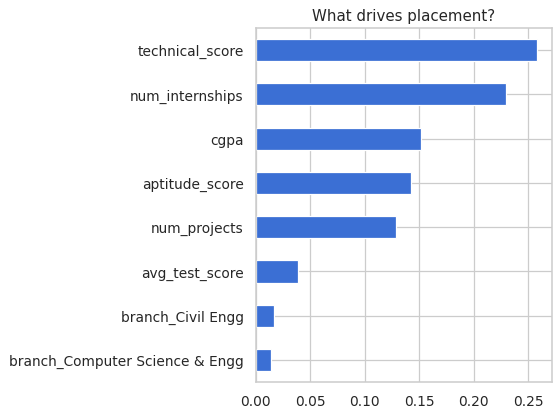

In [8]:
imp = pd.Series(clf["Random Forest"].feature_importances_, index=X.columns).sort_values()
imp.tail(8).plot.barh(color="#3b6fd4", title="What drives placement?"); plt.tight_layout(); plt.show()

Both models reach about 84% accuracy and about 0.90 AUC, so simple Logistic Regression is enough. Technical score and internships lead; branch adds only 1-2% once those are known.

## 5. Predict salary (regression)
Only placed students have a salary, so we train on them.

In [9]:
pl = df[df.placed == 1]
Xs = pd.concat([pl[num], pd.get_dummies(pl["branch"], prefix="branch")], axis=1); ys = pl["salary_lpa"]
Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=42)
reg = {"Linear Regression": LinearRegression(),
       "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
       "Gradient Boosting": GradientBoostingRegressor(random_state=42)}
print("Baseline MAE (predict median):", round(mean_absolute_error(yte, np.full(len(yte), ytr.median())), 2), "LPA")
out = {}
for n, m in reg.items():
    m.fit(Xtr, ytr); p = m.predict(Xte)
    out[n] = dict(MAE_LPA=mean_absolute_error(yte, p), R2=r2_score(yte, p))
pd.DataFrame(out).T.round(3)

Baseline MAE (predict median): 5.18 LPA


,MAE_LPA,R2
Linear Regression,3.902,0.487
Random Forest,2.144,0.798
Gradient Boosting,2.496,0.743


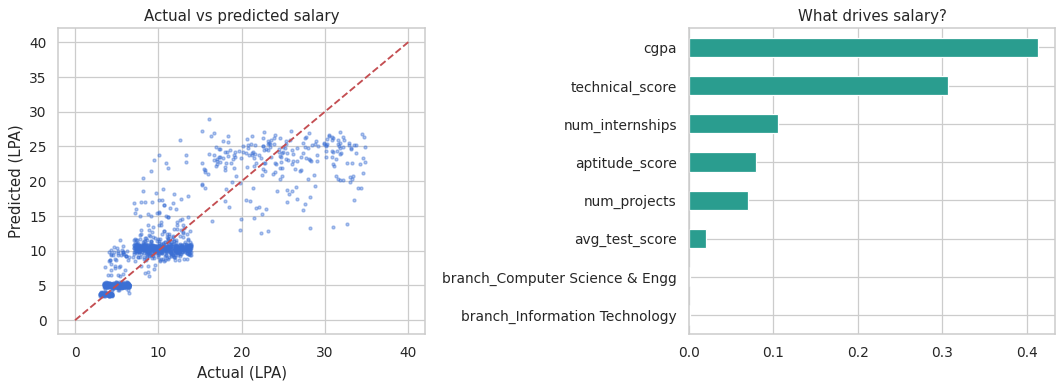

In [10]:
rf = reg["Random Forest"]; p = rf.predict(Xte)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(yte, p, s=6, alpha=.4, color="#3b6fd4"); ax[0].plot([0, 40], [0, 40], "r--")
ax[0].set_xlabel("Actual (LPA)"); ax[0].set_ylabel("Predicted (LPA)"); ax[0].set_title("Actual vs predicted salary")
pd.Series(rf.feature_importances_, index=Xs.columns).sort_values().tail(8).plot.barh(ax=ax[1], color="#2a9d8f", title="What drives salary?")
plt.tight_layout(); plt.show()

Random Forest predicts salary with MAE about 2.1 LPA (baseline about 5.2) and R² about 0.80. CGPA and technical score drive salary; internships matter more for getting placed than for how much you earn.

## 6. Conclusion
- Build 1-2 internships and projects early, keep CGPA above 8, and strengthen technical skills.
- Prepare for service companies first (most seats), and build projects for product firms (top pay).

**Limitations:** synthetic dataset, so patterns may differ from real colleges; no date column.